# Reconstructing tiles using feature vectors

Ideas:
- Condition injection via cross-attention (like in Stable Diffusion)
- Feature projection to match the diffusion model's conditioning space
- Guidance scale to control genomic influence strength

In [1]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from huggingface_hub import hf_hub_download, login
from torchvision import transforms
import h5py

from mopadi.configs.templates import tcga_brca_autoenc
from mopadi.utils.encode import *

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Must be first cell
device = "cuda:0"

In [2]:
# download model files
autoenc_model_path = hf_hub_download(
    repo_id="KatherLab/MoPaDi",
    filename="brca_512_model/autoenc.ckpt",
)
print(f"Autoencoder's checkpoint downloaded to: {autoenc_model_path}")

Autoencoder's checkpoint downloaded to: /home/maralampert/.cache/huggingface/hub/models--KatherLab--MoPaDi/snapshots/5d8e775e24473c5d8f4c0c57fd5c865c3c2a4aab/brca_512_model/autoenc.ckpt


In [3]:
data_dir = "/mnt/bulk-saturn/maralampert/genhist/data/TCGA/"

In [4]:
diffusion_encoder = ImageEncoder(
        tcga_brca_autoenc(), 
        autoenc_path="split_ckpts/diffusion_without_encoder.ckpt", 
        feat_extractor = None,
        device="cuda:0"
)

Seed set to 0


In [7]:
encoder = ImageEncoder(
        tcga_brca_autoenc(), 
        autoenc_path="split_ckpts/encoder_only.ckpt", 
        feat_extractor = None,
        device="cuda:0"
)

Seed set to 0


Loaded genomic features: torch.Size([1, 512]) (num_tiles x 512)
Conditioning shape: torch.Size([1, 512]) (B, D)


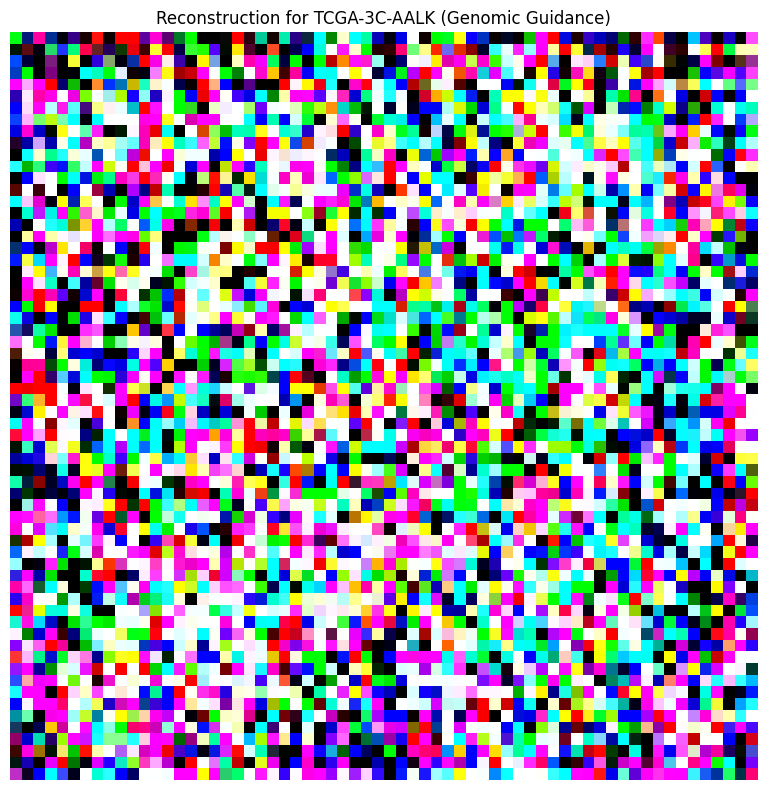

In [15]:
# --- 2. LOAD GENOMIC FEATURES ---
patient_id = "TCGA-3C-AALK"
feature_path = f"/mnt/bulk-saturn/maralampert/genhist/512_vae/mopadi_features/train/{patient_id}.h5"

with h5py.File(feature_path, "r") as hdf_file:
    all_tile_features = np.array(hdf_file['feats'])  # [num_tiles, 512]

genomic_vec = torch.tensor(all_tile_features, dtype=torch.float32).to(device)
print(f"Loaded genomic features: {genomic_vec.shape} (num_tiles x 512)")

# --- 3. CORRECT CONDITIONING FORMAT (FINAL FIX) ---
global_genomic = genomic_vec.mean(dim=0, keepdim=True)  # [1, 512]

# CRITICAL: Reshape to [1, 512] (2D tensor) for proper linear layer processing
cond_features = global_genomic  # [1, 512] - NO SPATIAL DIMENSIONS!
print(f"Conditioning shape: {cond_features.shape} (B, D)")

# --- 4. CORRECT NOISE TENSOR (3 CHANNELS) ---
noise = torch.randn(1, 3, 64, 64).to(device)

# Generate with corrected conditioning format
reconstructed = diffusion_encoder.decode_image(noise, cond_features)

# --- 5. POST-PROCESS AND DISPLAY ---
recon_np = reconstructed.squeeze().float().cpu().permute(1, 2, 0).numpy()
recon_np = (recon_np * 255).astype(np.uint8)

# Display results
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(recon_np)
ax.set_title(f"Reconstruction for {patient_id} (Genomic Guidance)")
ax.axis("off")
plt.tight_layout()
plt.show()